# Regressão Linear Bayesiana
Modelo inicial:
$$
    y = X \beta + \epsilon      \\

    \epsilon \sim \mathcal{N}(0, \sigma^2 I)
$$

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import bambi as bmb
import arviz as az

In [19]:
kidiq = pd.read_csv('../data/kidiq.csv')

In [20]:
modelo = smf.ols('kid_score ~ mom_hs*mom_iq', data=kidiq).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:              kid_score   R-squared:                       0.230
Model:                            OLS   Adj. R-squared:                  0.225
Method:                 Least Squares   F-statistic:                     42.84
Date:                Mon, 15 Jun 2026   Prob (F-statistic):           3.07e-24
Time:                        10:47:16   Log-Likelihood:                -1867.5
No. Observations:                 434   AIC:                             3743.
Df Residuals:                     430   BIC:                             3759.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept       -11.4820     13.758     -0.835

Agora vamos ajustar o seguinte modelo:
$$
    y = X \beta + \epsilon      \\
    \epsilon \sim \mathcal{N}(0, \sigma^2 I)        \\
    \beta \sim \mathcal{N}(0, \frac{25}{4}I)        \\
    \sigma \sim Exponencial(1)
$$

a ideia dessas prioris é que elas sejam _pouco informativas_. Vamos usar um pacote chamado **bambi** para realizar essas contas, ele utiliza de um algoritmo de Cadeias de Markov de Monte Carlo (MCMC) chamado Hamiltonian Monte Carlo para ter estimativas aproximadas de
$$
    p_X (\beta, \sigma^2|y) \propto f_X (y|\beta, \sigma^2) \pi_{B,S} (\beta, \sigma^2)
$$

In [21]:
bmod = bmb.Model('kid_score ~ mom_hs * mom_iq', data=kidiq)
bfit = bmod.fit()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, mom_hs, mom_iq, mom_hs:mom_iq]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.


In [22]:
az.summary(bfit)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sigma,18,0.63,17,19,2648,2393,1.00,0.012,0.0086
Intercept,-9.8,13.6,-31,12,1113,1541,1.00,0.4,0.28
mom_hs,49.3,15.2,25,73,998,1414,1.00,0.48,0.33
mom_iq,0.951,0.146,0.72,1.2,1125,1632,1.00,0.0044,0.003
mom_hs:mom_iq,-0.46,0.161,-0.72,-0.2,993,1349,1.00,0.0051,0.0035


Depois de checar os diagnósticos do MCMC (Rhat $\lt 1.01$ e ESS $\gt 500$ para todos os parâmet-
ros), vemos que as estimativas dos coeficientes não são radicalmente diferentes daquelas obtidas
com o método clássico/frequentista. Isso não chega a ser surpresa porque temos uma quanti-
dade razoável de observações ($n = 434$) em relação ao número de parâmetros.

Agora que temos uma distribuição a posteriori para as quantidades desconhecidas do modelo,
vamos utilizá-la para explorar o modelo e analisar o seu ajuste aos dados. Vamos computar a
distribuição preditiva a posteriori de certas quantidades e comparar essas distribuições com os
valores observados nos dados. Chamamos esse procedimento genérico de checagem preditiva
a posteriori (em inglês, posterior predictive checks [PPC]). Vamos começar com densidade da
variável dependente
$$
    p_X(\hat{y}|y) = \int_{\Omega} f_X (y|\theta)p_X(\theta|y)d\theta
$$

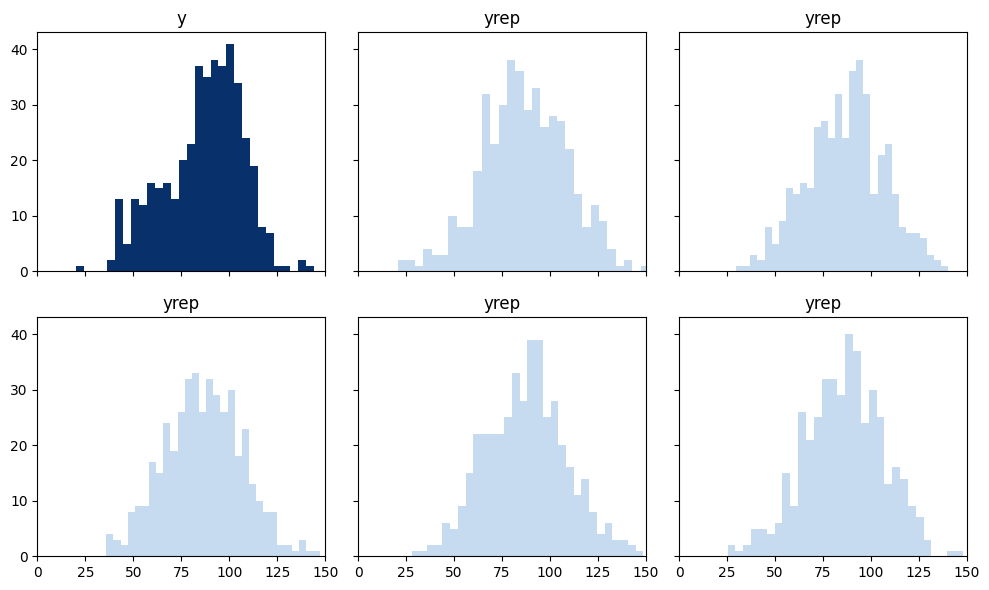

In [25]:
# Garantir que existem amostras preditivas a posteriori
if "posterior_predictive" not in bfit:
    bmod.predict(bfit, kind="response")

# Extrair observado e réplicas
y_obs = bfit.observed_data["kid_score"].values
ppc = bfit.posterior_predictive["kid_score"].stack(sample=("chain", "draw")).values
# ppc shape: (n_obs, n_samples)

rng = np.random.default_rng(42)
idx = rng.choice(ppc.shape[1], size=5, replace=False)

# Gráfico 1: histogramas y vs 5 amostras de y_rep
fig, axes = plt.subplots(2, 3, figsize=(10, 6), sharex=True, sharey=True)
axes = axes.flatten()

axes[0].hist(y_obs, bins=30, color="#08306b")
axes[0].set_title("y")

for i, ax in enumerate(axes[1:]):
    ax.hist(ppc[:, idx[i]], bins=30, color="#c6dbef")
    ax.set_title("yrep")

for ax in axes:
    ax.set_xlim(0, 150)

plt.tight_layout()
plt.show()

A ideia desse gráfico é a seguinte: para cada amostra $(\beta^{(s)}, \sigma^{(s)})$ da posteriori, eu posso simular um conjunto de dados novos $y_{rep}^{(s)}$ usando a mesma matriz de desenho $X$ e o modelo $y = X\beta^{(s)} + \epsilon$, com $\epsilon \sim N(0, (\sigma^{(s)})^2 I)$.

O primeiro histograma (escuro) mostra a distribuição dos dados reais ($y$, os `kid_score` observados). Os outros cinco (claros) são histogramas de cinco réplicas $y_{rep}$ diferentes, cada uma simulada com um conjunto de parâmetros sorteado da posteriori.

O que eu quero ver é se os histogramas claros se parecem com o escuro — mesma forma, mesma localização, mesma dispersão. Se sim, é um indício de que o modelo captura bem o comportamento global dos dados. Se as réplicas fossem muito diferentes (por exemplo, com formato bimodal quando os dados reais são unimodais, ou faixas de valores muito distintas), isso seria sinal de que o modelo está mal especificado.

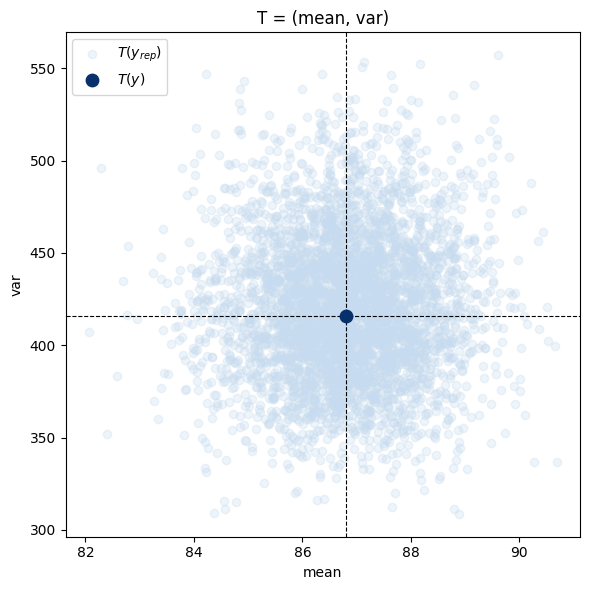

In [26]:
# Gráfico 2: T = (mean, var)
T_mean_rep = ppc.mean(axis=0)
T_var_rep = ppc.var(axis=0)

T_mean_obs = y_obs.mean()
T_var_obs = y_obs.var()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(T_mean_rep, T_var_rep, alpha=0.3, color="#c6dbef", label=r"$T(y_{rep})$")
ax.scatter(T_mean_obs, T_var_obs, color="#08306b", s=80, label=r"$T(y)$", zorder=5)
ax.axhline(T_var_obs, ls="--", color="black", lw=0.8)
ax.axvline(T_mean_obs, ls="--", color="black", lw=0.8)
ax.set_xlabel("mean")
ax.set_ylabel("var")
ax.set_title("T = (mean, var)")
ax.legend()
plt.tight_layout()
plt.show()

Aqui a ideia é resumir cada réplica $y_{rep}^{(s)}$ por duas estatísticas: a média e a variância. Em vez de olhar só 5 réplicas, agora eu simulo muitas (uma para cada amostra da posteriori), calculo $T(y_{rep}^{(s)}) = (\text{mean}, \text{var})$ para cada uma, e ploto essa nuvem de pontos claros.

O ponto escuro é $T(y) = (\text{mean}(y), \text{var}(y))$, ou seja, a média e a variância dos dados reais.

A pergunta que esse gráfico responde é: o ponto observado cai "no meio" da nuvem de pontos simulados, ou em uma região improvável/extrema? Se cai no meio, é um bom sinal de que o modelo reproduz bem esses dois momentos dos dados observados. Se caísse na borda ou fora da nuvem, seria evidência de que o modelo erra sistematicamente a média ou a variância.

No caso do `kid_score`, ambos os gráficos indicam que o modelo está bem calibrado para média e variância — embora, como visto depois com o quantil 95%, ele não capture tão bem a cauda da distribuição.

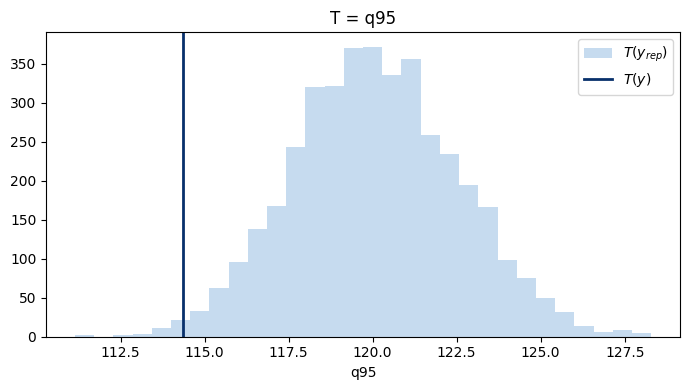

In [27]:
# Gráfico: pp_check com plotfun = "stat", stat = "q95"
# Compara a distribuição do quantil 95% das réplicas y_rep com o quantil 95% observado

T_q95_rep = np.quantile(ppc, 0.95, axis=0)
T_q95_obs = np.quantile(y_obs, 0.95)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(T_q95_rep, bins=30, color="#c6dbef", label=r"$T(y_{rep})$")
ax.axvline(T_q95_obs, color="#08306b", lw=2, label=r"$T(y)$")
ax.set_xlabel("q95")
ax.set_title("T = q95")
ax.legend()
plt.tight_layout()
plt.show()

Esse gráfico segue a mesma lógica do gráfico de mean/var, mas agora a estatística $T$ é o quantil 95% ($q95$) em vez da média e variância. Para cada réplica $y_{rep}^{(s)}$ simulada da posteriori, calculo $T(y_{rep}^{(s)}) = q95(y_{rep}^{(s)})$, e o histograma claro mostra a distribuição desses valores ao longo de todas as amostras.

A linha escura é $T(y) = q95(y)$, o quantil 95% dos dados observados.

Diferente do gráfico anterior, aqui o valor observado (linha escura) cai numa região de baixa densidade da distribuição simulada — bem deslocado para a esquerda em relação ao grosso da massa de $T(y_{rep})$. Ou seja, o modelo tende a gerar réplicas cujo quantil 95% é sistematicamente maior do que o quantil 95% dos dados reais.

Isso significa que o modelo está "exagerando" na cauda superior da distribuição preditiva: ele prevê que valores extremos de `kid_score` são mais comuns/maiores do que de fato ocorrem nos dados.

Isso é esperado e não é um problema grave. Um modelo de regressão linear gaussiana é construído para modelar bem a média condicional e a variância dos dados (que é exatamente o que vimos no gráfico anterior), não a forma completa da distribuição — em particular, não a cauda. A suposição de erros $\epsilon \sim N(0, \sigma^2 I)$ impõe uma cauda gaussiana simétrica, que pode não corresponder à cauda real dos dados (que aqui parece ser mais leve/limitada do que a normal sugere, possivelmente porque `kid_score` tem um limite superior natural). Portanto, esse descompasso na cauda é uma limitação conhecida e aceitável desse tipo de modelo, e não indica que o ajuste do modelo como um todo esteja ruim.

---

Agora eu vou construir duas matrizes de desenho hipotéticas $\tilde{X}$: uma fixando `mom_hs = 1` (mãe com ensino médio) e outra com `mom_hs = 0` (mãe sem ensino médio), variando `mom_iq` de 75 a 135 em passos de 5. Para cada uma das 13 combinações de cada grupo, gerei amostras da distribuição preditiva a posteriori $\tilde{p}_{\tilde{X}}(\tilde{y}\mid y)$, ou seja, para cada uma das 4000 amostras posteriores $(\beta^{(s)}, \sigma^{(s)})$ simulei $\tilde{y}^{(s)} = \tilde{X}\beta^{(s)} + \epsilon^{(s)}$.

Cada boxplot representa a distribuição dessas 4000 predições para um valor fixo de QI da mãe. Como vem de `posterior_predict` (e não só de $\tilde{X}\beta$), a largura de cada caixa incorpora tanto a incerteza sobre os parâmetros do modelo quanto o ruído de observação $\epsilon \sim N(0,\sigma^2)$ — é a distribuição preditiva completa para uma criança nova, não apenas a incerteza sobre a média condicional.

Comparando os dois painéis, dá pra ver o efeito da interação `mom_hs:mom_iq`: a inclinação da relação entre QI da mãe e score previsto da criança é diferente entre os grupos. No painel "Mom No HS" a inclinação é mais acentuada, enquanto no "Mom HS" ela é mais suave — reflexo direto do coeficiente de interação negativo estimado pelo modelo.

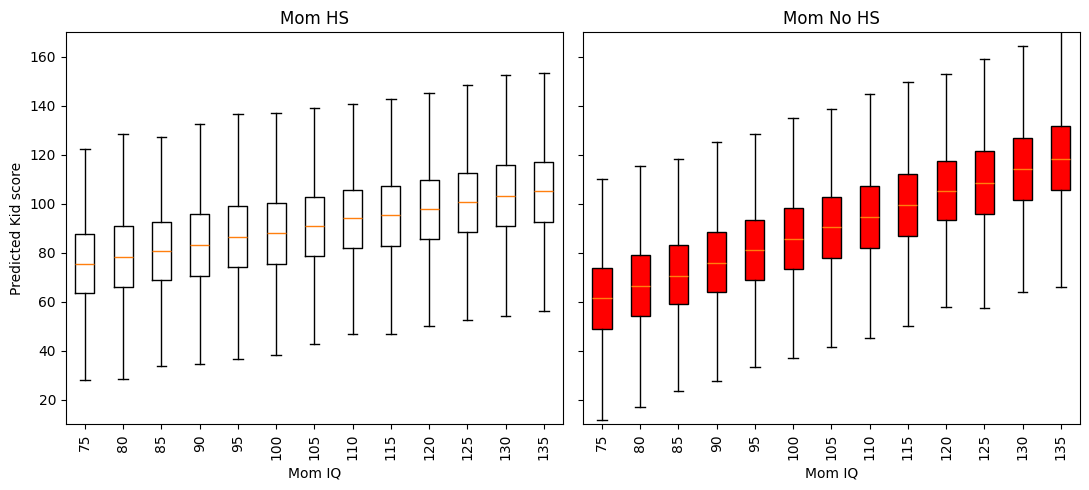

In [30]:
# Predições a posteriori para diferentes valores de mom_iq, separadas por mom_hs
IQ_SEQ = np.arange(75, 136, 5)

newdata_hs = pd.DataFrame({"mom_hs": 1, "mom_iq": IQ_SEQ})
newdata_nohs = pd.DataFrame({"mom_hs": 0, "mom_iq": IQ_SEQ})

# kind="response" inclui o ruído de observação (epsilon), equivalente ao posterior_predict do R
pred_hs = bmod.predict(bfit, data=newdata_hs, kind="response", inplace=False)
pred_nohs = bmod.predict(bfit, data=newdata_nohs, kind="response", inplace=False)

y_hs = pred_hs.posterior_predictive["kid_score"].stack(sample=("chain", "draw")).values.T   # (n_samples, 13)
y_nohs = pred_nohs.posterior_predictive["kid_score"].stack(sample=("chain", "draw")).values.T

# Gráfico: dois boxplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

axes[0].boxplot(y_hs, showfliers=False, tick_labels=IQ_SEQ)
axes[0].set_title("Mom HS")
axes[0].set_xlabel("Mom IQ")
axes[0].set_ylabel("Predicted Kid score")
axes[0].set_ylim(10, 170)
axes[0].tick_params(axis='x', rotation=90)

axes[1].boxplot(y_nohs, showfliers=False, tick_labels=IQ_SEQ,
                patch_artist=True, boxprops=dict(facecolor="red"))
axes[1].set_title("Mom No HS")
axes[1].set_xlabel("Mom IQ")
axes[1].set_ylim(10, 170)
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()